In [ ]:
pip install kumoai

In [32]:
import os
from getpass import getpass
import kumoai.experimental.rfm as rfm

# Prompt once if key is not already set in the environment.
if not os.environ.get("KUMO_API_KEY"):
    os.environ["KUMO_API_KEY"] = getpass("Enter KUMO_API_KEY: ").strip()

# Keep local graph workflow usable even if remote auth fails.
try:
    rfm.init()
    print("rfm.init() succeeded: authenticated with Kumo.")
except Exception as exc:
    print("rfm.init() failed (remote auth). LocalGraph can still be used locally.")
    print(f"Auth error: {exc}")

[2026-04-19 03:59:49 - kumoai:93 - WARNING] Failed to fetch feature flags: 403 Client Error: Forbidden for url: https://kumorfm.ai/api/config
[2026-04-19 03:59:49 - kumoai:245 - INFO] Initialized Kumo SDK v2.20.3 against deployment 'https://kumorfm.ai/api'


rfm.init() succeeded: authenticated with Kumo.


In [9]:
import pandas as pd
from pathlib import Path
import re

data_root = Path(r"C:\Users\Syed Haque\Documents\DataHacks2026")

if not data_root.exists():
    raise FileNotFoundError(f"Folder not found: {data_root}")

csv_files = sorted(data_root.rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found under: {data_root}")

dfs = {}
load_summary = []
load_errors = []
used_names = {}

for file_path in csv_files:
    # Build a stable dataframe name from file stem.
    base_name = re.sub(r"[^0-9a-zA-Z]+", "_", file_path.stem).strip("_").lower() or "dataset"
    suffix = used_names.get(base_name, 0)
    used_names[base_name] = suffix + 1
    df_name = base_name if suffix == 0 else f"{base_name}_{suffix + 1}"

    try:
        df = pd.read_csv(file_path)
        dfs[df_name] = df
        globals()[df_name] = df
        load_summary.append(
            {
                "dataframe": df_name,
                "file": str(file_path),
                "rows": int(df.shape[0]),
                "cols": int(df.shape[1]),
                "status": "loaded",
            }
        )
    except Exception as exc:
        load_errors.append(
            {
                "dataframe": df_name,
                "file": str(file_path),
                "error": str(exc),
            }
        )

summary_df = pd.DataFrame(load_summary).sort_values("dataframe").reset_index(drop=True)

print(f"CSV files found: {len(csv_files)}")
print(f"DataFrames loaded: {len(dfs)}")
display(summary_df)

if load_errors:
    print(f"Load errors: {len(load_errors)}")
    display(pd.DataFrame(load_errors))

print("Dictionary key sample:", list(dfs.keys())[:10])

CSV files found: 6
DataFrames loaded: 6


,dataframe,file,rows,cols,status
0,freedom_forever,C:\Users\Syed Haque\Documents\DataHacks2026\fr...,14964,3,loaded
1,records,C:\Users\Syed Haque\Documents\DataHacks2026\re...,37901,20,loaded
2,solar_city_permits,C:\Users\Syed Haque\Documents\DataHacks2026\so...,4689,92,loaded
3,sullivan_solar,C:\Users\Syed Haque\Documents\DataHacks2026\Su...,6192,11,loaded
4,sunrun,C:\Users\Syed Haque\Documents\DataHacks2026\su...,68403,3,loaded
5,titan_all_addresses,C:\Users\Syed Haque\Documents\DataHacks2026\Ti...,91218,12,loaded


Dictionary key sample: ['freedom_forever', 'records', 'solar_city_permits', 'sullivan_solar', 'sunrun', 'titan_all_addresses']


In [ ]:
# Quick schema peek for graph mapping
for name, df in dfs.items():
    print(f"\n{name}: rows={df.shape[0]}, cols={df.shape[1]}")
    print(df.columns.tolist())



freedom_forever: rows=14964, cols=3
['CONTRACTOR_NAME', 'PROJECT_ADDRESS', 'INSTALL_DATE']

records: rows=37901, cols=20
['id', 'created_at', 'source_id', 'source_type', 'permit_id', 'permit_type', 'kind', 'company_name', 'kilowatt_value', 'issue_date', 'apply_date', 'latitude', 'longitude', 'full_address', 'city', 'state', 'county', 'postal_code', 'is_active', 'is_system_size_estimation']

solar_city_permits: rows=4689, cols=92
['BIZ_NAME', 'ID', 'PERMIT_NUMBER', 'APN', 'COUNTY_FIPS', 'STATE_FIPS', 'CBSA', 'CBSA_FIPS', 'STATUS', 'START_DATE', 'END_DATE', 'ISSUE_DATE', 'FILE_DATE', 'FINAL_DATE', 'TYPE', 'SUBTYPE', 'APPROVAL_DURATION', 'CONSTRUCTION_DURATION', 'TOTAL_DURATION', 'FEES', 'JOB_VALUE', 'INSPECTION_PASS_RATE', 'INSPECTION_PASSED', 'DESCRIPTION', 'OWNER_NAME', 'OWNER_STREET', 'OWNER_CITY', 'OWNER_STATE', 'OWNER_ZIPCODE', 'OWNER_EMAIL', 'OWNER_PHONE', 'APPLICANT_NAME', 'APPLICANT_STREET', 'APPLICANT_CITY', 'APPLICANT_STATE', 'APPLICANT_ZIPCODE', 'APPLICANT_EMAIL', 'APPLICANT_

In [ ]:
import os
import kumoai.experimental.rfm as rfm

# LocalGraph.from_data works without remote auth; only initialize if credentials exist.
if os.environ.get("KUMO_API_KEY"):
    rfm.init()
    print("rfm initialized with KUMO_API_KEY")
else:
    print("KUMO_API_KEY not set; skipping rfm.init() for local graph work.")

KUMO_API_KEY not set; skipping rfm.init() for local graph work.


In [10]:
import pandas as pd
import kumoai.experimental.rfm as rfm

# Use all loaded datasets and improve address linking with strict+fallback keys.

def _norm_text(s: pd.Series) -> pd.Series:
    return s.fillna("").astype(str).str.strip().str.lower()


def _build_address_fields(df: pd.DataFrame, text_col: str, city_col: str | None = None, state_col: str | None = None, zip_col: str | None = None) -> pd.DataFrame:
    out = df.copy()
    out["address_text"] = out[text_col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    out["city_n"] = _norm_text(out[city_col]) if city_col and city_col in out.columns else ""
    out["state_n"] = _norm_text(out[state_col]) if state_col and state_col in out.columns else ""
    out["zip_n"] = _norm_text(out[zip_col]) if zip_col and zip_col in out.columns else ""
    out["address_key_full"] = _norm_text(out["address_text"]) + "|" + out["city_n"] + "|" + out["state_n"] + "|" + out["zip_n"]
    out["address_key_loose"] = _norm_text(out["address_text"])
    return out


# Source tables
records_src = _build_address_fields(records, "full_address", "city", "state", "postal_code")
freedom_src = _build_address_fields(freedom_forever, "PROJECT_ADDRESS")
sunrun_src = _build_address_fields(sunrun, "PROJECT_ADDRESS")

solar_tmp = solar_city_permits.copy()
solar_tmp["address_concat"] = (
    solar_tmp[["STREET_NO", "STREET", "CITY", "STATE", "ZIPCODE"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
solar_src = _build_address_fields(solar_tmp, "address_concat", "CITY", "STATE", "ZIPCODE")

sullivan_tmp = sullivan_solar.copy()
sullivan_tmp["address_concat"] = (
    sullivan_tmp[["STREET_NO", "STREET", "CITY", "STATE", "ZIPCODE"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
sullivan_src = _build_address_fields(sullivan_tmp, "address_concat", "CITY", "STATE", "ZIPCODE")

titan_tmp = titan_all_addresses.copy()
titan_tmp["address_concat"] = (
    titan_tmp[["STREET_NO", "STREET", "CITY", "STATE", "ZIPCODE"]]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
titan_src = _build_address_fields(titan_tmp, "address_concat", "CITY", "STATE", "ZIPCODE")

# Shared contractors dimension
contractor_names = pd.concat([
    records_src["company_name"].fillna("UNKNOWN_CONTRACTOR").astype(str),
    freedom_src["CONTRACTOR_NAME"].fillna("UNKNOWN_CONTRACTOR").astype(str),
    sunrun_src["CONTRACTOR_NAME"].fillna("UNKNOWN_CONTRACTOR").astype(str),
    solar_src["BIZ_NAME"].fillna("UNKNOWN_CONTRACTOR").astype(str),
    sullivan_src["BIZ_NAME"].fillna("UNKNOWN_CONTRACTOR").astype(str),
    titan_src["BIZ_NAME"].fillna("UNKNOWN_CONTRACTOR").astype(str),
], ignore_index=True)

contractors = pd.DataFrame({"contractor_name": contractor_names.str.strip()})
contractors = contractors[contractors["contractor_name"] != ""].drop_duplicates().reset_index(drop=True)
contractors["contractor_id"] = contractors.index.astype("int64") + 1
contractors = contractors[["contractor_id", "contractor_name"]]
contractor_lookup = dict(zip(contractors["contractor_name"], contractors["contractor_id"]))

# Shared addresses dimension
addr_parts = []
for frame in [records_src, freedom_src, sunrun_src, solar_src, sullivan_src, titan_src]:
    addr_parts.append(frame[["address_text", "city_n", "state_n", "zip_n", "address_key_full", "address_key_loose"]])

addresses = pd.concat(addr_parts, ignore_index=True)
addresses = addresses[addresses["address_key_loose"] != ""].drop_duplicates(subset=["address_key_full", "address_key_loose"]).reset_index(drop=True)
addresses["address_id"] = addresses.index.astype("int64") + 1
addresses = addresses[["address_id", "address_key_full", "address_key_loose", "address_text", "city_n", "state_n", "zip_n"]]

full_lookup = dict(zip(addresses["address_key_full"], addresses["address_id"]))
loose_lookup = (
    addresses.sort_values(["address_key_loose", "city_n", "state_n", "zip_n"])
    .drop_duplicates(subset=["address_key_loose"])
    .set_index("address_key_loose")["address_id"]
    .to_dict()
)

# Shared permits dimension
permit_series = pd.concat([
    records_src["permit_id"].astype(str),
    solar_src["PERMIT_NUMBER"].astype(str),
    sullivan_src["PERMIT_ID"].astype(str),
    titan_src["PERMIT_ID"].astype(str),
], ignore_index=True).str.strip()
permits = pd.DataFrame({"permit_id": permit_series})
permits = permits[(permits["permit_id"] != "") & (permits["permit_id"].str.lower() != "nan")]
permits = permits.drop_duplicates().reset_index(drop=True)


def _attach_common_keys(df: pd.DataFrame, contractor_col: str) -> pd.DataFrame:
    out = df.copy()
    out["contractor_id"] = out[contractor_col].fillna("UNKNOWN_CONTRACTOR").astype(str).str.strip().map(contractor_lookup)
    out["address_id"] = out["address_key_full"].map(full_lookup)
    out["address_id"] = out["address_id"].fillna(out["address_key_loose"].map(loose_lookup)).astype("Int64")
    return out


records_src = _attach_common_keys(records_src, "company_name")
freedom_src = _attach_common_keys(freedom_src, "CONTRACTOR_NAME")
sunrun_src = _attach_common_keys(sunrun_src, "CONTRACTOR_NAME")
solar_src = _attach_common_keys(solar_src, "BIZ_NAME")
sullivan_src = _attach_common_keys(sullivan_src, "BIZ_NAME")
titan_src = _attach_common_keys(titan_src, "BIZ_NAME")

records_tbl = records_src[["id", "contractor_id", "address_id", "permit_id", "permit_type", "kind", "issue_date", "apply_date", "kilowatt_value"]].copy()
records_tbl = records_tbl.rename(columns={"id": "records_id"})
records_tbl["records_id"] = pd.to_numeric(records_tbl["records_id"], errors="coerce").fillna(0).astype("int64")

freedom_tbl = freedom_src[["contractor_id", "address_id", "INSTALL_DATE"]].copy()
freedom_tbl["freedom_forever_id"] = freedom_tbl.index.astype("int64") + 1
freedom_tbl = freedom_tbl[["freedom_forever_id", "contractor_id", "address_id", "INSTALL_DATE"]]

sunrun_tbl = sunrun_src[["contractor_id", "address_id", "INSTALL_DATE"]].copy()
sunrun_tbl["sunrun_id"] = sunrun_tbl.index.astype("int64") + 1
sunrun_tbl = sunrun_tbl[["sunrun_id", "contractor_id", "address_id", "INSTALL_DATE"]]

solar_tbl = solar_src[["ID", "contractor_id", "address_id", "PERMIT_NUMBER", "ISSUE_DATE", "FILE_DATE", "SOLAR"]].copy()
solar_tbl = solar_tbl.rename(columns={"ID": "solar_city_permits_id", "PERMIT_NUMBER": "permit_id"})
solar_tbl["solar_city_permits_id"] = pd.to_numeric(solar_tbl["solar_city_permits_id"], errors="coerce").fillna(0).astype("int64")

sullivan_tbl = sullivan_src[["PERMIT_ID", "contractor_id", "address_id", "PERMIT_DATE"]].copy()
sullivan_tbl["sullivan_solar_id"] = sullivan_tbl.index.astype("int64") + 1
sullivan_tbl = sullivan_tbl.rename(columns={"PERMIT_ID": "permit_id"})
sullivan_tbl = sullivan_tbl[["sullivan_solar_id", "contractor_id", "address_id", "permit_id", "PERMIT_DATE"]]

titan_tbl = titan_src[["PERMIT_ID", "contractor_id", "address_id", "PERMIT_DATE", "NAME", "PRIMARY_EMAIL", "PRIMARY_PHONE"]].copy()
titan_tbl["titan_all_addresses_id"] = titan_tbl.index.astype("int64") + 1
titan_tbl = titan_tbl.rename(columns={"PERMIT_ID": "permit_id"})
titan_tbl = titan_tbl[["titan_all_addresses_id", "contractor_id", "address_id", "permit_id", "PERMIT_DATE", "NAME", "PRIMARY_EMAIL", "PRIMARY_PHONE"]]

coverage = pd.DataFrame([
    {"table": "records", "address_link_rate": float(records_tbl["address_id"].notna().mean())},
    {"table": "freedom_forever", "address_link_rate": float(freedom_tbl["address_id"].notna().mean())},
    {"table": "sunrun", "address_link_rate": float(sunrun_tbl["address_id"].notna().mean())},
    {"table": "solar_city_permits", "address_link_rate": float(solar_tbl["address_id"].notna().mean())},
    {"table": "sullivan_solar", "address_link_rate": float(sullivan_tbl["address_id"].notna().mean())},
    {"table": "titan_all_addresses", "address_link_rate": float(titan_tbl["address_id"].notna().mean())},
])

print("Table shapes used in graph:")
print("contractors:", contractors.shape)
print("addresses:", addresses.shape)
print("permits:", permits.shape)
print("records:", records_tbl.shape)
print("freedom_forever:", freedom_tbl.shape)
print("sunrun:", sunrun_tbl.shape)
print("solar_city_permits:", solar_tbl.shape)
print("sullivan_solar:", sullivan_tbl.shape)
print("titan_all_addresses:", titan_tbl.shape)
print("\nAddress link coverage:")
display(coverage)

graph_all = rfm.LocalGraph.from_data({
    "contractors": contractors,
    "addresses": addresses,
    "permits": permits,
    "records": records_tbl,
    "freedom_forever": freedom_tbl,
    "sunrun": sunrun_tbl,
    "solar_city_permits": solar_tbl,
    "sullivan_solar": sullivan_tbl,
    "titan_all_addresses": titan_tbl,
})

try:
    graph_all.visualize(backend="mermaid")
except Exception as exc:
    print(f"Mermaid backend failed: {exc}")
    print("Trying graphviz backend...")
    graph_all.visualize(backend="graphviz")

Table shapes used in graph:
contractors: (2474, 2)
addresses: (173901, 7)
permits: (139616, 1)
records: (37901, 9)
freedom_forever: (14964, 4)
sunrun: (68403, 4)
solar_city_permits: (4689, 7)
sullivan_solar: (6192, 5)
titan_all_addresses: (91218, 8)

Address link coverage:


,table,address_link_rate
0,records,1.0
1,freedom_forever,1.0
2,sunrun,1.0
3,solar_city_permits,1.0
4,sullivan_solar,1.0
5,titan_all_addresses,1.0


### 🗂️ Graph Metadata

Name,Primary Key,Time Column,End Time Column
contractors,contractor_id,-,-
addresses,-,-,-
permits,permit_id,-,-
records,records_id,issue_date,-
freedom_forever,freedom_forever_id,INSTALL_DATE,-
sunrun,sunrun_id,-,-
solar_city_permits,solar_city_permits_id,FILE_DATE,-
sullivan_solar,sullivan_solar_id,PERMIT_DATE,-
titan_all_addresses,titan_all_addresses_id,PERMIT_DATE,-


### 🕸️ Graph Links (FK ↔️ PK)

- `freedom_forever.contractor_id` ↔️ `contractors.contractor_id`
- `records.contractor_id` ↔️ `contractors.contractor_id`
- `solar_city_permits.contractor_id` ↔️ `contractors.contractor_id`
- `sullivan_solar.contractor_id` ↔️ `contractors.contractor_id`
- `sunrun.contractor_id` ↔️ `contractors.contractor_id`
- `titan_all_addresses.contractor_id` ↔️ `contractors.contractor_id`
- `records.permit_id` ↔️ `permits.permit_id`
- `solar_city_permits.permit_id` ↔️ `permits.permit_id`
- `sullivan_solar.permit_id` ↔️ `permits.permit_id`
- `titan_all_addresses.permit_id` ↔️ `permits.permit_id`

In [4]:
# Backend sanity check in current kernel
import importlib.util
print("graphviz module found:", importlib.util.find_spec("graphviz") is not None)
print("mermaid module found:", importlib.util.find_spec("mermaid") is not None)
print("mermaid_py module found:", importlib.util.find_spec("mermaid_py") is not None)

graphviz module found: True
mermaid module found: True
mermaid_py module found: False


## Solar Opportunity Analysis (Question-Driven)

This section answers:
1. Potential savings per person/household
2. Potential savings per city/municipality
3. Environmental impact by city/state
4. Solar adoption hotspots
5. Fastest-changing cities (adoption growth)
6. Time/seasonality patterns
7. Geospatial insights for best solar cities

Notes:
- Results are data-scope estimates based on available permit/adoption records.
- Assumptions are configurable in the next cell.


Unified adoption events: 223,367
Events with city/state: 137,998
Records with explicit kW size: 37,901
Median system size used for imputation: 7.92 kW

Q1 - Potential savings per person/household (sample top 10, filtered to kw < 100):


,address,city,state,kw,annual_bill_savings_usd,annual_co2_kg_avoided
37117,"10 JEANNETTE PRANDI WAY, SAN RAFAEL, CA 94903",SAN RAFAEL,CA,99.360000,45944.064000,65200.032000
37679,"9075 FOOTHILL BLVD, 1, RANCHO CUCAMONGA, CA, 9...",RANCHO CUCAMONGA,CA,99.220000,45879.328000,65108.164000
2574,"23217, KIDDER, HAYWARD, CA, 94545, US",HAYWARD,CA,99.120000,45833.088000,65042.544000
8949,"1000 LITTLESTOWN PIKE, MD",,MD,99.000000,45777.600000,64963.800000
30357,"4000 REDWOOD RD, OAKLAND, CA, 94619, US",OAKLAND,CA,98.900000,45731.360000,64898.180000
29168,"85 VERNON ST, 110, OAKLAND, CA, 94610, US",OAKLAND,CA,98.133333,45376.853333,64395.093333
30365,"85 VERNON ST, OAKLAND, CA, 94610, US",OAKLAND,CA,98.133333,45376.853333,64395.093333
32266,"5252 REDONDO AVE, OAKLAND, CA, 94618, US",OAKLAND,CA,98.000000,45315.200000,64307.600000
19708,"980 INDUSTRIAL BL, A/1, CHULA VISTA, CA, US",CHULA VISTA,CA,97.200000,44945.280000,63782.640000
25625,"150, 72, PEMBROKE PINES, FL, 33024",PEMBROKE PINES,FL,96.800000,44760.320000,63520.160000


Typical household estimate (median system): $3,662/year

Q2 - Cities with highest estimated annual savings potential:


,state,city,unique_addresses,annual_savings_usd_potential
467,CA,OAKLAND,3387,1.932533e+07
389,CA,LOS ANGELES,5286,1.929463e+07
559,CA,SAN DIEGO,3131,1.622137e+07
938,FL,PORT CHARLOTTE,2521,9.232426e+06
326,CA,INDIO,1499,9.145459e+06
514,CA,PLEASANT HILL,1186,8.085742e+06
47,AZ,PEORIA,2095,7.672326e+06
182,CA,CHULA VISTA,530,7.038933e+06
18,AZ,BUCKEYE,1838,6.731138e+06
299,CA,HANFORD,1702,6.596580e+06



Q3 - State-level annual CO2 avoided estimate (tons):


...

,state,city,monthly_growth_slope,total_events
131,NV,HENDERSON,11.400000,179
0,AL,MOBILE,8.714286,166
39,CA,JURUPA VALLEY,8.600000,128
109,HI,HI,7.428571,185
95,CO,BOULDER,6.581818,150
130,NJ,JERSEY CITY,5.257143,110
71,CA,SAN JACINTO,4.900000,163
125,MO,KANSAS CITY,4.800000,60
27,CA,GLENDORA,3.742857,57
148,TX,LUBBOCK,2.800000,20



Q6 - Month-of-year seasonality (all city-tagged events):


,month,events
0,1,3273
1,2,3707
2,3,6810
3,4,3421
4,5,2131
5,6,2124
6,7,2122
7,8,2454
8,9,2643
9,10,2874



Q7 - Best solar cities (composite score):


,state,city,best_solar_city_score,annual_savings_usd_potential,adoption_events,monthly_growth_slope,avg_lat,avg_lon
142,CA,LOS ANGELES,0.828897,1.929463e+07,7725,0.000000,33.998666,-118.292127
193,CA,SAN DIEGO,0.635782,1.622137e+07,3978,0.239319,32.807265,-117.125188
164,CA,OAKLAND,0.609865,1.932533e+07,3608,-4.608724,37.804309,-122.213560
335,FL,PORT CHARLOTTE,0.525836,9.232426e+06,4680,0.000000,NaN,NaN
23,AZ,PEORIA,0.436564,7.672326e+06,3113,0.000000,NaN,NaN
119,CA,INDIO,0.419364,9.145459e+06,1654,1.098790,33.728730,-116.236158
328,FL,PEMBROKE PINES,0.381832,6.381693e+06,1161,-0.089286,26.008298,-80.310652
7,AZ,BUCKEYE,0.372597,6.731138e+06,1908,0.000000,NaN,NaN
176,CA,PLEASANT HILL,0.353293,8.085742e+06,1273,0.000348,37.950615,-122.077536
484,TX,AUSTIN,0.349207,5.738680e+06,1769,0.000000,NaN,NaN


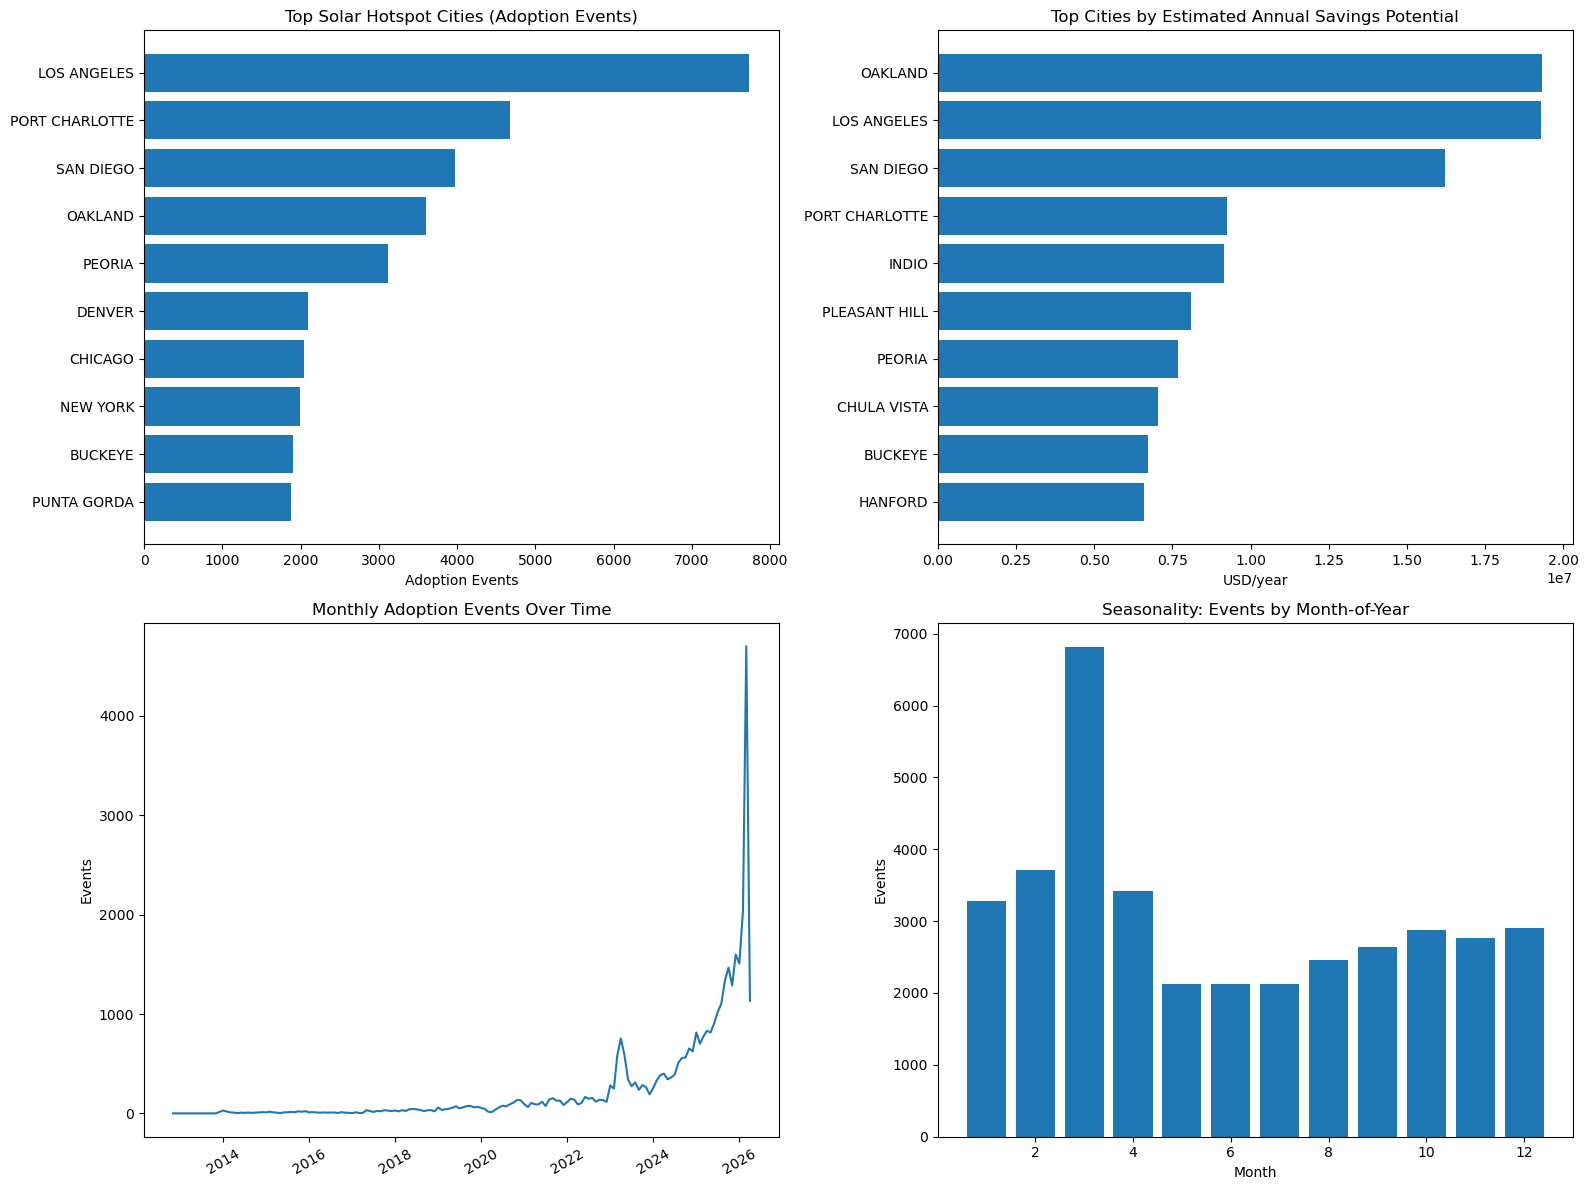

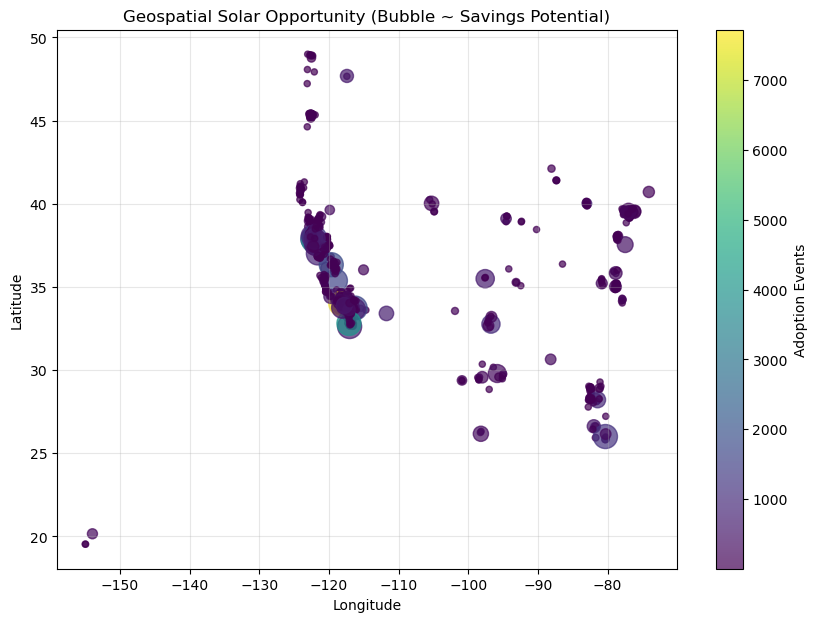

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Assumptions (edit as needed)
# -----------------------------
ASSUMPTIONS = {
    "annual_kwh_per_kw": 1700,        # yearly kWh generated per 1 kW solar installed
    "retail_rate_usd_per_kwh": 0.32,  # electricity price
    "bill_offset_ratio": 0.85,        # portion of generated electricity that offsets bill
    "co2_kg_per_kwh": 0.386,          # avoided grid CO2 intensity
}


def _safe_dt(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce")


def _clean_str(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip()


# ---------------------------------
# Build unified adoption event table
# ---------------------------------
records_ev = pd.DataFrame({
    "source": "records",
    "date": _safe_dt(records["issue_date"]).fillna(_safe_dt(records["apply_date"])),
    "city": _clean_str(records["city"]),
    "state": _clean_str(records["state"]),
    "address": _clean_str(records["full_address"]),
    "lat": pd.to_numeric(records["latitude"], errors="coerce"),
    "lon": pd.to_numeric(records["longitude"], errors="coerce"),
    "kw": pd.to_numeric(records["kilowatt_value"], errors="coerce"),
})

solar_ev = pd.DataFrame({
    "source": "solar_city_permits",
    "date": _safe_dt(solar_city_permits["ISSUE_DATE"]).fillna(_safe_dt(solar_city_permits["FILE_DATE"])),
    "city": _clean_str(solar_city_permits["CITY"]),
    "state": _clean_str(solar_city_permits["STATE"]),
    "address": (
        solar_city_permits[["STREET_NO", "STREET", "CITY", "STATE", "ZIPCODE"]]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    ),
    "lat": pd.to_numeric(solar_city_permits["LAT"], errors="coerce"),
    "lon": pd.to_numeric(solar_city_permits["LONG"], errors="coerce"),
    "kw": np.nan,
})

sullivan_ev = pd.DataFrame({
    "source": "sullivan_solar",
    "date": _safe_dt(sullivan_solar["PERMIT_DATE"]),
    "city": _clean_str(sullivan_solar["CITY"]),
    "state": _clean_str(sullivan_solar["STATE"]),
    "address": (
        sullivan_solar[["STREET_NO", "STREET", "CITY", "STATE", "ZIPCODE"]]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    ),
    "lat": np.nan,
    "lon": np.nan,
    "kw": np.nan,
})

titan_ev = pd.DataFrame({
    "source": "titan_all_addresses",
    "date": _safe_dt(titan_all_addresses["PERMIT_DATE"]),
    "city": _clean_str(titan_all_addresses["CITY"]),
    "state": _clean_str(titan_all_addresses["STATE"]),
    "address": (
        titan_all_addresses[["STREET_NO", "STREET", "CITY", "STATE", "ZIPCODE"]]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    ),
    "lat": np.nan,
    "lon": np.nan,
    "kw": np.nan,
})

freedom_ev = pd.DataFrame({
    "source": "freedom_forever",
    "date": _safe_dt(freedom_forever["INSTALL_DATE"]),
    "city": "",
    "state": "",
    "address": _clean_str(freedom_forever["PROJECT_ADDRESS"]),
    "lat": np.nan,
    "lon": np.nan,
    "kw": np.nan,
})

sunrun_ev = pd.DataFrame({
    "source": "sunrun",
    "date": _safe_dt(sunrun["INSTALL_DATE"]),
    "city": "",
    "state": "",
    "address": _clean_str(sunrun["PROJECT_ADDRESS"]),
    "lat": np.nan,
    "lon": np.nan,
    "kw": np.nan,
})

all_events = pd.concat(
    [records_ev, solar_ev, sullivan_ev, titan_ev, freedom_ev, sunrun_ev],
    ignore_index=True,
)
all_events["date"] = pd.to_datetime(all_events["date"], errors="coerce")
all_events["city"] = all_events["city"].replace("", pd.NA)
all_events["state"] = all_events["state"].replace("", pd.NA)
all_events["address"] = all_events["address"].replace("", pd.NA)

median_kw = records_ev["kw"].dropna().median()
if pd.isna(median_kw):
    median_kw = 6.0

print(f"Unified adoption events: {len(all_events):,}")
print(f"Events with city/state: {all_events['city'].notna().sum():,}")
print(f"Records with explicit kW size: {records_ev['kw'].notna().sum():,}")
print(f"Median system size used for imputation: {median_kw:.2f} kW")

# --------------------------------------------------
# Q1: Potential savings per person/household (proxy)
# --------------------------------------------------
person_base = records_ev.dropna(subset=["kw", "address"]).copy()
person_base = person_base[(person_base["kw"] > 0) & (person_base["kw"] < 100)]
person_base["annual_kwh"] = person_base["kw"] * ASSUMPTIONS["annual_kwh_per_kw"]
person_base["annual_bill_savings_usd"] = (
    person_base["annual_kwh"] * ASSUMPTIONS["retail_rate_usd_per_kwh"] * ASSUMPTIONS["bill_offset_ratio"]
)
person_base["annual_co2_kg_avoided"] = person_base["annual_kwh"] * ASSUMPTIONS["co2_kg_per_kwh"]

person_summary = person_base[["address", "city", "state", "kw", "annual_bill_savings_usd", "annual_co2_kg_avoided"]].copy()
person_summary = person_summary.sort_values("annual_bill_savings_usd", ascending=False)

print("\nQ1 - Potential savings per person/household (sample top 10, filtered to kw < 100):")
display(person_summary.head(10))
print(
    "Typical household estimate (median system): "
    f"${median_kw * ASSUMPTIONS['annual_kwh_per_kw'] * ASSUMPTIONS['retail_rate_usd_per_kwh'] * ASSUMPTIONS['bill_offset_ratio']:,.0f}/year"
)

# -------------------------------------------------------------
# Q2 + Q3 + Q4 + Q7: City/state savings, environment, hotspots
# -------------------------------------------------------------
city_events = all_events.dropna(subset=["city", "state"]).copy()
city_events["address_key"] = _clean_str(city_events["address"]).str.lower().fillna("missing_addr")

city_stats = (
    city_events.groupby(["state", "city"], dropna=False)
    .agg(
        adoption_events=("source", "size"),
        unique_addresses=("address_key", "nunique"),
        known_kw_records=("kw", lambda x: x.notna().sum()),
        total_known_kw=("kw", "sum"),
        avg_lat=("lat", "mean"),
        avg_lon=("lon", "mean"),
    )
    .reset_index()
)
city_stats["imputed_total_kw"] = city_stats["total_known_kw"].fillna(0) + (city_stats["unique_addresses"] - city_stats["known_kw_records"]).clip(lower=0) * median_kw
city_stats["annual_kwh_potential"] = city_stats["imputed_total_kw"] * ASSUMPTIONS["annual_kwh_per_kw"]
city_stats["annual_savings_usd_potential"] = (
    city_stats["annual_kwh_potential"] * ASSUMPTIONS["retail_rate_usd_per_kwh"] * ASSUMPTIONS["bill_offset_ratio"]
)
city_stats["annual_co2_tons_avoided"] = (
    city_stats["annual_kwh_potential"] * ASSUMPTIONS["co2_kg_per_kwh"] / 1000.0
)

hotspots = city_stats.sort_values("adoption_events", ascending=False).head(15)
city_savings = city_stats.sort_values("annual_savings_usd_potential", ascending=False).head(15)
state_env = (
    city_stats.groupby("state", dropna=False)["annual_co2_tons_avoided"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("\nQ2 - Cities with highest estimated annual savings potential:")
display(city_savings[["state", "city", "unique_addresses", "annual_savings_usd_potential"]])

print("\nQ3 - State-level annual CO2 avoided estimate (tons):")
display(state_env.head(15))

print("\nQ4 - Solar hotspots by adoption events:")
display(hotspots[["state", "city", "adoption_events", "unique_addresses"]])

# ---------------------------------------------------
# Q5 + Q6: Fastest-changing cities and seasonality
# ---------------------------------------------------
city_time = city_events.copy()
city_time["date"] = pd.to_datetime(city_time["date"], errors="coerce")
city_time = city_time.dropna(subset=["date"])
city_time["month"] = city_time["date"].dt.to_period("M").dt.to_timestamp()

monthly_city = (
    city_time.groupby(["state", "city", "month"], dropna=False)
    .size()
    .reset_index(name="count")
)

# City growth slope: linear trend of monthly counts
slope_rows = []
for (st, ct), grp in monthly_city.groupby(["state", "city"], dropna=False):
    grp = grp.sort_values("month")
    if len(grp) < 4 or grp["count"].sum() < 20:
        continue
    x = np.arange(len(grp))
    y = grp["count"].to_numpy(dtype=float)
    slope = np.polyfit(x, y, 1)[0]
    slope_rows.append({"state": st, "city": ct, "monthly_growth_slope": slope, "total_events": int(y.sum())})

fastest_changing = pd.DataFrame(slope_rows).sort_values("monthly_growth_slope", ascending=False)

monthly_total = city_time.groupby(city_time["date"].dt.to_period("M").dt.to_timestamp()).size()
month_of_year = city_time.groupby(city_time["date"].dt.month).size().reindex(range(1, 13), fill_value=0)

print("\nQ5 - Fastest-changing cities (monthly adoption acceleration):")
display(fastest_changing.head(15))

print("\nQ6 - Month-of-year seasonality (all city-tagged events):")
seasonality_df = pd.DataFrame({"month": range(1, 13), "events": month_of_year.values})
display(seasonality_df)

# ---------------------------------------------------
# Q7: Geospatial suitability score for solar cities
# ---------------------------------------------------
geo = city_stats.copy()
geo = geo[geo["adoption_events"] >= 20].copy()

if not fastest_changing.empty:
    geo = geo.merge(
        fastest_changing[["state", "city", "monthly_growth_slope"]],
        on=["state", "city"],
        how="left",
    )
else:
    geo["monthly_growth_slope"] = 0.0
geo["monthly_growth_slope"] = geo["monthly_growth_slope"].fillna(0.0)

# Crude irradiance proxy: lower absolute latitude tends to higher insolation.
geo["irradiance_proxy"] = 1.0 - (geo["avg_lat"].abs() / 90.0)
geo["irradiance_proxy"] = geo["irradiance_proxy"].fillna(geo["irradiance_proxy"].median())

for col in ["adoption_events", "annual_savings_usd_potential", "monthly_growth_slope", "irradiance_proxy"]:
    lo, hi = geo[col].min(), geo[col].max()
    geo[f"{col}_norm"] = 0.0 if hi == lo else (geo[col] - lo) / (hi - lo)

geo["best_solar_city_score"] = (
    0.30 * geo["adoption_events_norm"]
    + 0.35 * geo["annual_savings_usd_potential_norm"]
    + 0.20 * geo["monthly_growth_slope_norm"]
    + 0.15 * geo["irradiance_proxy_norm"]
)

best_cities = geo.sort_values("best_solar_city_score", ascending=False)

print("\nQ7 - Best solar cities (composite score):")
display(best_cities[["state", "city", "best_solar_city_score", "annual_savings_usd_potential", "adoption_events", "monthly_growth_slope", "avg_lat", "avg_lon"]].head(20))

# ----------------
# Visualization
# ----------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

hotspots_plot = hotspots.sort_values("adoption_events", ascending=True).tail(10)
axes[0, 0].barh(hotspots_plot["city"].astype(str), hotspots_plot["adoption_events"])
axes[0, 0].set_title("Top Solar Hotspot Cities (Adoption Events)")
axes[0, 0].set_xlabel("Adoption Events")

city_savings_plot = city_savings.sort_values("annual_savings_usd_potential", ascending=True).tail(10)
axes[0, 1].barh(city_savings_plot["city"].astype(str), city_savings_plot["annual_savings_usd_potential"])
axes[0, 1].set_title("Top Cities by Estimated Annual Savings Potential")
axes[0, 1].set_xlabel("USD/year")

if len(monthly_total) > 0:
    axes[1, 0].plot(monthly_total.index, monthly_total.values)
axes[1, 0].set_title("Monthly Adoption Events Over Time")
axes[1, 0].set_ylabel("Events")
axes[1, 0].tick_params(axis="x", rotation=30)

axes[1, 1].bar(range(1, 13), month_of_year.values)
axes[1, 1].set_title("Seasonality: Events by Month-of-Year")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("Events")

plt.tight_layout()
plt.show()

# Optional geospatial scatter where lat/lon available
geo_points = city_stats.dropna(subset=["avg_lat", "avg_lon"]).copy()
if not geo_points.empty:
    plt.figure(figsize=(10, 7))
    sc = plt.scatter(
        geo_points["avg_lon"],
        geo_points["avg_lat"],
        s=np.clip(geo_points["annual_savings_usd_potential"] / 2e4, 20, 300),
        c=geo_points["adoption_events"],
        alpha=0.7,
    )
    plt.colorbar(sc, label="Adoption Events")
    plt.title("Geospatial Solar Opportunity (Bubble ~ Savings Potential)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, alpha=0.3)
    plt.show()


In [13]:
# Optional: inspect available Kumo RFM API surface in this environment
import kumoai.experimental.rfm as rfm
print([name for name in dir(rfm) if not name.startswith("_")])

['Enum', 'ExplainConfig', 'Explanation', 'Graph', 'InferenceBackend', 'KumoClient', 'KumoClient_SageMakerAdapter', 'KumoClient_SageMakerProxy_Local', 'KumoRFM', 'LocalGraph', 'LocalTable', 'RfmGlobalState', 'Table', 'TaskTable', 'authenticate', 'backend', 'base', 'dataclass', 'global_state', 'graph', 'infer', 'init', 'ipaddress', 'kumoai', 'logger', 'logging', 'os', 'pquery', 're', 'rfm', 'sagemaker', 'socket', 'task_table', 'threading', 'urlparse']


In [14]:
# Optional: inspect KumoRFM methods
print([name for name in dir(rfm.KumoRFM) if not name.startswith("_")])

['add_lagged_target', 'batch_mode', 'evaluate', 'evaluate_task', 'get_train_table', 'predict', 'predict_task', 'retry', 'update_connection']


In [15]:
# Optional: inspect Graph/LocalGraph methods
print("Graph methods:", [name for name in dir(rfm.Graph) if not name.startswith("_")])
print("LocalGraph methods:", [name for name in dir(rfm.LocalGraph) if not name.startswith("_")])

Graph methods: ['add_table', 'backend', 'edges', 'from_data', 'from_relbench', 'from_snowflake', 'from_snowflake_semantic_view', 'from_sqlite', 'graph_and_pquery_from_timeseries', 'has_table', 'infer_links', 'infer_metadata', 'link', 'metadata', 'print_links', 'print_metadata', 'remove_table', 'table', 'tables', 'unlink', 'update_connection', 'validate', 'visualize']
LocalGraph methods: ['add_table', 'backend', 'edges', 'from_data', 'from_relbench', 'from_snowflake', 'from_snowflake_semantic_view', 'from_sqlite', 'graph_and_pquery_from_timeseries', 'has_table', 'infer_links', 'infer_metadata', 'link', 'metadata', 'print_links', 'print_metadata', 'remove_table', 'table', 'tables', 'unlink', 'update_connection', 'validate', 'visualize']


In [17]:
# Optional: inspect infer/pquery module contents
print("infer module entries:", [n for n in dir(rfm.infer) if not n.startswith("_")][:80])
print("pquery module entries:", [n for n in dir(rfm.pquery) if not n.startswith("_")][:80])

infer module entries: ['categorical', 'contains_categorical', 'contains_id', 'contains_multicategorical', 'contains_timestamp', 'dtype', 'id', 'infer_dtype', 'infer_primary_key', 'infer_stype', 'infer_time_column', 'multicategorical', 'pkey', 'stype', 'time_col', 'timestamp']
pquery module entries: ['PQueryExecutor', 'PQueryPandasExecutor', 'executor', 'pandas_executor']


In [18]:
# Optional: inspect rfm.rfm module entries
print([n for n in dir(rfm.rfm) if not n.startswith("_")])

['Aggregation', 'AggregationType', 'Any', 'CastMixin', 'ClassificationInferenceConfig', 'Column', 'Condition', 'Console', 'Constant', 'Context', 'DataBackend', 'ExplainConfig', 'Explanation', 'ExplanationConfig', 'Generator', 'Graph', 'HTTPException', 'InferenceConfig', 'Iterator', 'Join', 'KumoRFM', 'Literal', 'LogicalOperation', 'Markdown', 'ProblemType', 'ProgressLogger', 'QueryType', 'RFMAPI', 'RFMEvaluateRequest', 'RFMParseQueryRequest', 'RFMPredictRequest', 'RegressionInferenceConfig', 'RunMode', 'Sampler', 'Sequence', 'Stype', 'Table', 'TaskTable', 'TaskType', 'Timestamp', 'ValidatedPredictiveQuery', 'contextmanager', 'dataclass', 'defaultdict', 'display', 'format_value', 'in_notebook', 'json', 'math', 'np', 'overload', 'pd', 'replace', 'time', 'warnings']


In [19]:
# Optional: inspect KumoRFM signatures
import inspect
print("KumoRFM:", inspect.signature(rfm.KumoRFM))
print("KumoRFM.predict:", inspect.signature(rfm.KumoRFM.predict))
print("KumoRFM.evaluate:", inspect.signature(rfm.KumoRFM.evaluate))

KumoRFM: (graph: kumoai.experimental.rfm.graph.Graph, verbose: bool | kumoai.utils.progress_logger.ProgressLogger = True, optimize: bool = False) -> None
KumoRFM.predict: (self, query: str | kumoapi.pquery.validated_predictive_query.ValidatedPredictiveQuery, indices: collections.abc.Sequence[str] | collections.abc.Sequence[float] | collections.abc.Sequence[int] | None = None, *, explain: bool | kumoai.experimental.rfm.rfm.ExplainConfig | dict[str, typing.Any] = False, return_embeddings: bool = False, anchor_time: Union[pandas._libs.tslibs.timestamps.Timestamp, Literal['entity'], NoneType] = None, context_anchor_time: pandas._libs.tslibs.timestamps.Timestamp | None = None, run_mode: kumoapi.model_plan.RunMode | str = fast, num_neighbors: list[int] | None = None, use_prediction_time: bool = False, lag_timesteps: int = 0, inference_config: kumoapi.rfm.inference.InferenceConfig | dict[str, typing.Any] | None = None, num_hops: int = 2, max_pq_iterations: int = 10, random_seed: int | None = 

In [20]:
# Optional: inspect task-related signatures for this Kumo version
import inspect
print("TaskTable:", inspect.signature(rfm.TaskTable))
print("Graph.add_table:", inspect.signature(rfm.Graph.add_table))
print("KumoRFM.get_train_table:", inspect.signature(rfm.KumoRFM.get_train_table))
print("KumoRFM.evaluate_task:", inspect.signature(rfm.KumoRFM.evaluate_task))
print("KumoRFM.predict_task:", inspect.signature(rfm.KumoRFM.predict_task))

TaskTable: (task_type: kumoapi.task.TaskType, context_df: pandas.core.frame.DataFrame, pred_df: pandas.core.frame.DataFrame, entity_table_name: str | collections.abc.Sequence[str], entity_column: str, target_column: str, time_column: str | None = None, step_size: int | None = None, num_forecasts: int = 1) -> None
Graph.add_table: (self, table: 'Table') -> 'Self'
KumoRFM.get_train_table: (self, query: str | kumoapi.pquery.validated_predictive_query.ValidatedPredictiveQuery, size: int, *, anchor_time: Union[pandas._libs.tslibs.timestamps.Timestamp, Literal['entity'], NoneType] = None, random_seed: int | None = 42, max_iterations: int = 10) -> pandas.core.frame.DataFrame
KumoRFM.evaluate_task: (self, task: kumoai.experimental.rfm.task_table.TaskTable, *, metrics: list[str] | None = None, run_mode: kumoapi.model_plan.RunMode | str = fast, num_neighbors: list[int] | None = None, inference_config: kumoapi.rfm.inference.InferenceConfig | dict[str, typing.Any] | None = None, num_hops: int = 2,

In [21]:
# Optional: inspect task type enums
print("TaskType:", list(rfm.rfm.TaskType))

TaskType: [binary_classification, multiclass_classification, multilabel_classification, multilabel_ranking, regression, temporal_link_prediction, static_link_prediction, forecasting, link_prediction]


## Kumo Predictive Workflows (City Growth + Savings Ranking)

This section builds two Kumo tasks on top of city-level features:
1. Forecasting monthly solar adoption events per city
2. Regression-based city savings potential scoring

If remote authentication fails, the cells will still prepare all task tables and show where to provide a valid key.


In [23]:
import numpy as np
import pandas as pd
import kumoai.experimental.rfm as rfm

# Reuse analysis outputs if already present.
required_vars = ["city_events", "city_stats", "fastest_changing"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing required variables from the analysis section: "
        f"{missing}. Run Cell 9 first, then rerun this cell."
    )

# -------------------------
# Build city-level entities
# -------------------------
city_dim = city_stats[["state", "city", "adoption_events", "unique_addresses", "annual_savings_usd_potential", "annual_co2_tons_avoided", "avg_lat", "avg_lon"]].copy()
city_dim["state"] = city_dim["state"].fillna("UNKNOWN").astype(str).str.strip()
city_dim["city"] = city_dim["city"].fillna("UNKNOWN").astype(str).str.strip()
city_dim["city_key"] = city_dim["state"] + "|" + city_dim["city"]
city_dim = city_dim.drop_duplicates(subset=["city_key"]).reset_index(drop=True)
city_dim["city_id"] = city_dim.index.astype("int64") + 1

city_id_lookup = dict(zip(city_dim["city_key"], city_dim["city_id"]))

# -----------------------------------
# Monthly city fact table (forecasting)
# -----------------------------------
city_monthly = city_events.dropna(subset=["date", "state", "city"]).copy()
city_monthly["state"] = city_monthly["state"].astype(str).str.strip()
city_monthly["city"] = city_monthly["city"].astype(str).str.strip()
city_monthly["city_key"] = city_monthly["state"] + "|" + city_monthly["city"]
city_monthly["city_id"] = city_monthly["city_key"].map(city_id_lookup)
city_monthly = city_monthly.dropna(subset=["city_id"]).copy()
city_monthly["city_id"] = city_monthly["city_id"].astype("int64")
city_monthly["month"] = pd.to_datetime(city_monthly["date"], errors="coerce").dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()

monthly_counts = (
    city_monthly.groupby(["city_id", "month"], as_index=False)
    .size()
    .rename(columns={"size": "monthly_events"})
    .sort_values(["city_id", "month"])
)
monthly_counts["next_month_events"] = (
    monthly_counts.groupby("city_id")["monthly_events"].shift(-1)
)

# Keep only rows where future target exists for supervised forecasting/evaluation.
forecast_train = monthly_counts.dropna(subset=["next_month_events"]).copy()
forecast_train["next_month_events"] = forecast_train["next_month_events"].astype(float)

# Predict set: latest month per city.
forecast_pred = (
    monthly_counts.sort_values(["city_id", "month"]).groupby("city_id", as_index=False).tail(1).copy()
)
forecast_pred["next_month_events"] = np.nan

# --------------------------------------
# City savings task table (regression)
# --------------------------------------
city_features = city_dim[["city_id", "state", "city", "adoption_events", "unique_addresses", "annual_co2_tons_avoided", "avg_lat", "avg_lon", "annual_savings_usd_potential"]].copy()

if "monthly_growth_slope" in fastest_changing.columns:
    growth_map = fastest_changing[["state", "city", "monthly_growth_slope"]].copy()
    growth_map["state"] = growth_map["state"].astype(str).str.strip()
    growth_map["city"] = growth_map["city"].astype(str).str.strip()
    city_features = city_features.merge(growth_map, on=["state", "city"], how="left")
else:
    city_features["monthly_growth_slope"] = 0.0

city_features["monthly_growth_slope"] = city_features["monthly_growth_slope"].fillna(0.0)

savings_context = city_features.copy()
savings_pred = city_features.copy()
savings_pred["annual_savings_usd_potential"] = np.nan

print("Prepared Kumo task dataframes:")
print("city_dim:", city_dim.shape)
print("monthly_counts:", monthly_counts.shape)
print("forecast_train:", forecast_train.shape)
print("forecast_pred:", forecast_pred.shape)
print("savings_context:", savings_context.shape)


Prepared Kumo task dataframes:
city_dim: (1749, 10)
monthly_counts: (4914, 4)
forecast_train: (4246, 4)
forecast_pred: (668, 4)
savings_context: (1749, 10)


In [36]:
# Build a Kumo graph for city-level tasks and run forecasting + regression

# Use explicit LocalTable definitions so primary/time columns are unambiguous.
cities_table = rfm.LocalTable(
    city_dim,
    name="cities",
    primary_key="city_id",
)
city_monthly_table = rfm.LocalTable(
    monthly_counts,
    name="city_monthly",
    time_column="month",
)

kumo_city_graph = rfm.LocalGraph([cities_table, city_monthly_table])
kumo_city_graph.link("city_monthly", "city_id", "cities")

kumo_city_graph.validate()
print("Kumo city graph tables:", list(kumo_city_graph.tables.keys()))
kumo_city_graph.print_links()

kumo_model = rfm.KumoRFM(kumo_city_graph, verbose=True)

# -------------------------------
# 1) Forecast next-month adoption
# -------------------------------
# This SDK version requires forecasting one entity at a time.
city_priority = (
    city_dim[["city_id", "state", "city", "adoption_events"]]
    .sort_values("adoption_events", ascending=False)
    .head(25)
)

forecast_rows = []
forecast_failures = []
for row in city_priority.itertuples(index=False):
    cid = int(row.city_id)
    c_state = row.state
    c_city = row.city

    ctx = forecast_train[forecast_train["city_id"] == cid].copy()
    pred = forecast_pred[forecast_pred["city_id"] == cid].copy()

    if len(ctx) < 6 or pred.empty:
        continue

    one_task = rfm.TaskTable(
        task_type=rfm.rfm.TaskType.FORECASTING,
        context_df=ctx,
        pred_df=pred,
        entity_table_name="cities",
        entity_column="city_id",
        target_column="next_month_events",
        time_column="month",
        step_size=1,
        num_forecasts=1,
    )

    try:
        out = kumo_model.predict_task(one_task)
        pred_col = "TARGET_PRED" if "TARGET_PRED" in out.columns else ("prediction" if "prediction" in out.columns else None)
        pred_val = float(out[pred_col].iloc[0]) if pred_col and len(out) else np.nan
        forecast_rows.append(
            {
                "city_id": cid,
                "state": c_state,
                "city": c_city,
                "pred_next_month_events": pred_val,
            }
        )
    except Exception as exc:
        forecast_failures.append({"city_id": cid, "state": c_state, "city": c_city, "error": str(exc)})

forecast_ranked = pd.DataFrame(forecast_rows).sort_values("pred_next_month_events", ascending=False)

print("\nTop cities by predicted next-month adoption (entity-by-entity forecast):")
if not forecast_ranked.empty:
    display(forecast_ranked.head(20))
else:
    print("No forecast predictions returned.")

if forecast_failures:
    print(f"Forecast failures for {len(forecast_failures)} cities (showing up to 5):")
    display(pd.DataFrame(forecast_failures).head(5))

# ---------------------------------------
# 2) City savings regression (ranking use)
# ---------------------------------------
reg_features = city_dim[[
    "city_id",
    "adoption_events",
    "unique_addresses",
    "annual_co2_tons_avoided",
    "avg_lat",
    "avg_lon",
    "annual_savings_usd_potential",
]].copy()

# Add growth signal if available
if "fastest_changing" in globals() and not fastest_changing.empty:
    growth = fastest_changing[["state", "city", "monthly_growth_slope"]].copy()
    growth["state"] = growth["state"].astype(str).str.strip()
    growth["city"] = growth["city"].astype(str).str.strip()
    reg_features = reg_features.merge(
        city_dim[["city_id", "state", "city"]],
        on="city_id",
        how="left",
    ).merge(growth, on=["state", "city"], how="left")
    reg_features = reg_features.drop(columns=["state", "city"])
else:
    reg_features["monthly_growth_slope"] = 0.0

reg_features["monthly_growth_slope"] = reg_features["monthly_growth_slope"].fillna(0.0)
reg_features = reg_features.dropna(subset=["annual_savings_usd_potential"]).copy()

savings_context = reg_features.copy()
savings_pred = reg_features.copy()
savings_pred["annual_savings_usd_potential"] = np.nan

savings_task = rfm.TaskTable(
    task_type=rfm.rfm.TaskType.REGRESSION,
    context_df=savings_context,
    pred_df=savings_pred,
    entity_table_name="cities",
    entity_column="city_id",
    target_column="annual_savings_usd_potential",
)

try:
    savings_eval = kumo_model.evaluate_task(savings_task)
    savings_pred_out = kumo_model.predict_task(savings_task)

    print("\nSavings regression evaluation metrics:")
    display(savings_eval)

    pred_col = "TARGET_PRED" if "TARGET_PRED" in savings_pred_out.columns else ("prediction" if "prediction" in savings_pred_out.columns else None)
    if pred_col is None:
        raise RuntimeError(f"No prediction column found. Columns: {list(savings_pred_out.columns)}")

    city_id_col = "ENTITY" if "ENTITY" in savings_pred_out.columns else "city_id"
    savings_ranked = (
        savings_pred_out[[city_id_col, pred_col]]
        .rename(columns={city_id_col: "city_id", pred_col: "pred_annual_savings_usd"})
        .merge(city_dim[["city_id", "state", "city", "annual_savings_usd_potential"]], on="city_id", how="left")
        .sort_values("pred_annual_savings_usd", ascending=False)
    )
    print("\nTop cities by predicted annual savings potential:")
    display(savings_ranked.head(20))
except Exception as exc:
    print("Savings task execution failed.")
    print(f"Reason: {exc}")
    print("Kumo graph/task wiring is complete; retry after confirming account permissions for regression runs.")

Kumo city graph tables: ['cities', 'city_monthly']


### 🕸️ Graph Links (FK ↔️ PK)

- `city_monthly.city_id` ↔️ `cities.city_id`

Output()

Output()

...

Output()


Top cities by predicted next-month adoption (entity-by-entity forecast):


,city_id,state,city,pred_next_month_events
3,327,CA,INDIO,74.000000
1,468,CA,OAKLAND,62.608784
2,300,CA,HANFORD,41.821293
0,560,CA,SAN DIEGO,32.655411
5,515,CA,PLEASANT HILL,9.680576
4,425,CA,MILL VALLEY,6.000000
6,929,FL,PEMBROKE PINES,5.464301


Output()

Savings task execution failed.
Reason: An unexpected exception occurred. Please create an issue at 'https://github.com/kumo-ai/kumo-rfm'. Request failed due to application error: Model inference failed unexpectedly. If this issue persists after retrying, please report it at 'https://github.com/kumo-ai/kumo-rfm'. Please try again later or contact Kumo if the issue persists.
Kumo graph/task wiring is complete; retry after confirming account permissions for regression runs.


In [25]:
# Optional: inspect Graph.link signature
import inspect
print(inspect.signature(rfm.Graph.link))

(self, src_table: 'str | Table', fkey: 'str', dst_table: 'str | Table') -> 'Self'


In [26]:
# Optional: inspect LocalTable signature
import inspect
print(inspect.signature(rfm.LocalTable))

(df: pandas.core.frame.DataFrame, name: str, primary_key: kumoapi.model_plan.MissingType | str | None = ???, time_column: str | None = None, end_time_column: str | None = None) -> None


In [28]:
# Optional: inspect LocalGraph constructor signature
import inspect
print(inspect.signature(rfm.LocalGraph))

(tables: 'Sequence[Table]', edges: 'Sequence[EdgeLike] | None' = None) -> 'None'


In [30]:
# Optional: inspect TaskType members
print(rfm.rfm.TaskType.__members__)

{'BINARY_CLASSIFICATION': binary_classification, 'MULTICLASS_CLASSIFICATION': multiclass_classification, 'MULTILABEL_CLASSIFICATION': multilabel_classification, 'MULTILABEL_RANKING': multilabel_ranking, 'REGRESSION': regression, 'TEMPORAL_LINK_PREDICTION': temporal_link_prediction, 'STATIC_LINK_PREDICTION': static_link_prediction, 'FORECASTING': forecasting, 'LINK_PREDICTION': link_prediction}


In [35]:
# Debug: inspect one forecast_task output schema
sample_city_id = int(city_priority.iloc[0]["city_id"])
sample_ctx = forecast_train[forecast_train["city_id"] == sample_city_id].copy()
sample_pred = forecast_pred[forecast_pred["city_id"] == sample_city_id].copy()

sample_task = rfm.TaskTable(
    task_type=rfm.rfm.TaskType.FORECASTING,
    context_df=sample_ctx,
    pred_df=sample_pred,
    entity_table_name="cities",
    entity_column="city_id",
    target_column="next_month_events",
    time_column="month",
    step_size=1,
    num_forecasts=1,
)

sample_out = kumo_model.predict_task(sample_task)
print(type(sample_out))
if hasattr(sample_out, "columns"):
    print("columns:", list(sample_out.columns))
    display(sample_out.head())
else:
    print(sample_out)

Output()

<class 'pandas.core.frame.DataFrame'>
columns: ['ENTITY', 'ANCHOR_TIMESTAMP', 'TIME', 'TARGET_PRED']


,ENTITY,ANCHOR_TIMESTAMP,TIME,TARGET_PRED
0,390,2026-04-01,2026-04-01,17.000093


In [37]:
# Debug: probe query syntax for city savings regression
query_candidates = [
    "PREDICT cities.annual_savings_usd_potential FOR EACH cities.city_id",
    "PREDICT cities.annual_savings_usd_potential FOR cities.city_id",
    "PREDICT annual_savings_usd_potential FOR EACH cities.city_id",
    "PREDICT annual_savings_usd_potential FOR cities.city_id",
]

test_indices = city_dim["city_id"].head(5).tolist()
for q in query_candidates:
    print("\nTrying query:", q)
    try:
        q_out = kumo_model.predict(q, indices=test_indices)
        print("Success. Columns:", list(q_out.columns))
        display(q_out.head())
        working_query = q
        break
    except Exception as exc:
        print("Failed:", exc)
else:
    working_query = None

print("\nWorking query:", working_query)


Trying query: PREDICT cities.annual_savings_usd_potential FOR EACH cities.city_id


Output()

Success. Columns: ['ENTITY', 'ANCHOR_TIMESTAMP', 'TARGET_PRED']


,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,1,2026-04-01,3.662208e+03
1,2,2026-04-01,3.662208e+03
2,3,2026-04-01,7.324416e+03
3,4,2026-04-01,1.098662e+04
4,5,2026-04-01,1.228148e+06



Working query: PREDICT cities.annual_savings_usd_potential FOR EACH cities.city_id


In [38]:
# Option 2: Query-based Kumo savings prediction (no TaskTable)

# Ensure we have a model on the city graph.
if "kumo_model" not in globals() or "kumo_city_graph" not in globals():
    cities_table = rfm.LocalTable(city_dim, name="cities", primary_key="city_id")
    city_monthly_table = rfm.LocalTable(monthly_counts, name="city_monthly", time_column="month")
    kumo_city_graph = rfm.LocalGraph([cities_table, city_monthly_table])
    kumo_city_graph.link("city_monthly", "city_id", "cities")
    kumo_city_graph.validate()
    kumo_model = rfm.KumoRFM(kumo_city_graph, verbose=True)

query_savings = "PREDICT cities.annual_savings_usd_potential FOR EACH cities.city_id"
all_city_ids = city_dim["city_id"].tolist()

# Batch mode avoids max-entity limits in one request.
try:
    with kumo_model.batch_mode(batch_size="max", num_retries=1):
        savings_query_pred = kumo_model.predict(query_savings, indices=all_city_ids)

    pred_col = "TARGET_PRED" if "TARGET_PRED" in savings_query_pred.columns else "prediction"
    entity_col = "ENTITY" if "ENTITY" in savings_query_pred.columns else "city_id"

    savings_query_ranked = (
        savings_query_pred[[entity_col, pred_col]]
        .rename(columns={entity_col: "city_id", pred_col: "pred_annual_savings_usd"})
        .merge(city_dim[["city_id", "state", "city", "annual_savings_usd_potential", "adoption_events"]], on="city_id", how="left")
        .sort_values("pred_annual_savings_usd", ascending=False)
    )

    print("Query-based savings predictions completed.")
    print(f"Rows predicted: {len(savings_query_ranked):,}")
    display(savings_query_ranked.head(25))
except Exception as exc:
    print("Query-based savings prediction failed.")
    print(f"Reason: {exc}")

# Optional: evaluate query quality with Kumo's evaluator.
try:
    savings_query_eval = kumo_model.evaluate(query_savings)
    print("\nQuery evaluation metrics:")
    display(savings_query_eval)
except Exception as exc:
    print("Query evaluation skipped/failed.")
    print(f"Reason: {exc}")

Output()

Query-based savings predictions completed.
Rows predicted: 1,749


,city_id,pred_annual_savings_usd,state,city,annual_savings_usd_potential,adoption_events
389,390,16270547.0,CA,LOS ANGELES,1.929463e+07,7725
467,468,10902860.0,CA,OAKLAND,1.932533e+07,3608
326,327,7982105.5,CA,INDIO,9.145459e+06,1654
299,300,7585403.0,CA,HANFORD,6.596580e+06,1805
928,929,6512795.0,FL,PEMBROKE PINES,6.381693e+06,1161
514,515,6418889.5,CA,PLEASANT HILL,8.085742e+06,1273
303,304,6366531.5,CA,HAYWARD,4.737306e+06,902
281,282,5693277.0,CA,GILROY,5.439274e+06,793
938,939,5539123.5,FL,PORT CHARLOTTE,9.232426e+06,4680
47,48,5403262.0,AZ,PEORIA,7.672326e+06,3113


Output()


Query evaluation metrics:


,metric,value
0,mae,6.749730e+04
1,mse,5.567688e+11
2,rmse,7.461694e+05
